In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_PATH = os.path.join("..", "vr_legibility_train.csv")

In [9]:
#load the data set
df = pd.read_csv(DATA_PATH)[["Yaw", "Pitch", "FontSize", "Label"]]

print(df.head()) 
print("\n")
print(df.info())
#no missing values, all data types are numeric

     Yaw  Pitch  FontSize  Label
0 -37.97  38.91     122.9      1
1  19.42  29.49     201.0      0
2  29.65  28.99       6.5      1
3 -39.31 -14.70      75.3      0
4  15.48  -6.88      75.3      0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4869 entries, 0 to 4868
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Yaw       4869 non-null   float64
 1   Pitch     4869 non-null   float64
 2   FontSize  4869 non-null   float64
 3   Label     4869 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 152.3 KB
None


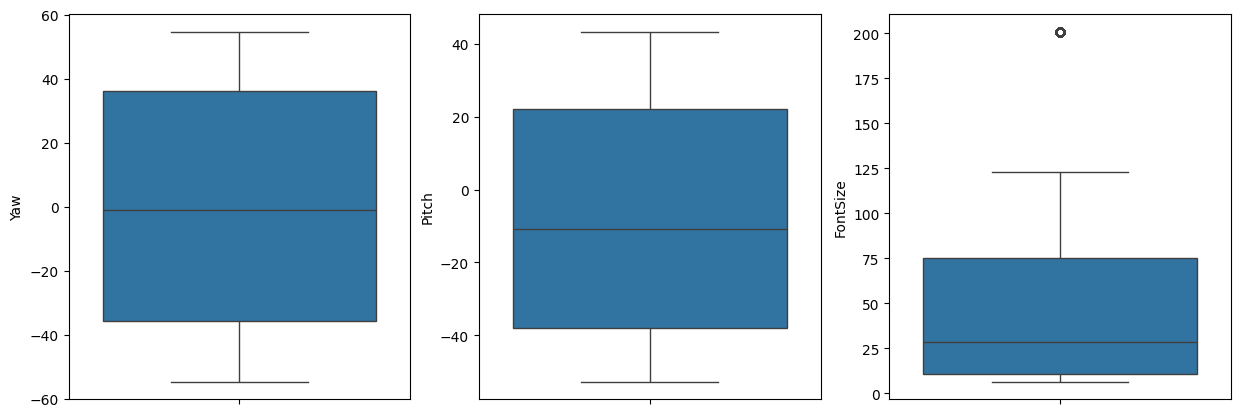

In [13]:
#Anomaly Detection

fig,axes = plt.subplots(1,3, figsize=(15,5))
sns.boxplot(data=df['Yaw'], ax=axes[0])
sns.boxplot(data=df['Pitch'], ax=axes[1])
sns.boxplot(data=df['FontSize'], ax=axes[2])
plt.show()
#no outliers detected in the data set

C:\Users\psgve\AppData\Local\Temp\ipykernel_28680\1613682387.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Label'], palette='Set2')


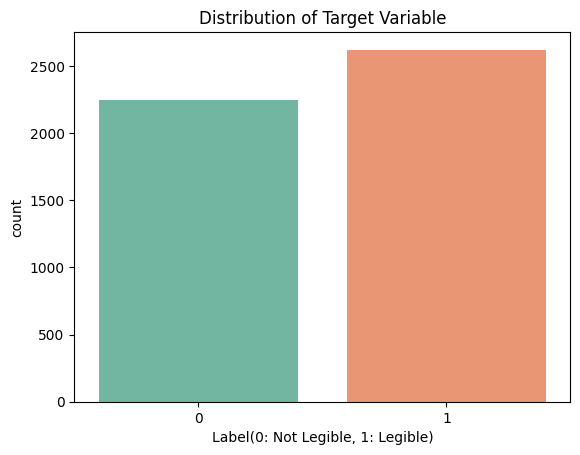

In [14]:
#target distribution

sns.countplot(x=df['Label'], palette='Set2')
plt.title("Distribution of Target Variable")
plt.xlabel("Label(0: Not Legible, 1: Legible)")
plt.show()

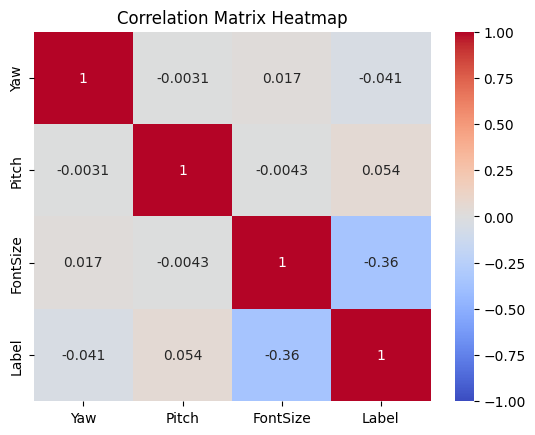

In [16]:
#multicollinearity check

correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, vmin=-1, cmap='coolwarm')

plt.title('Correlation Matrix Heatmap')
plt.show()


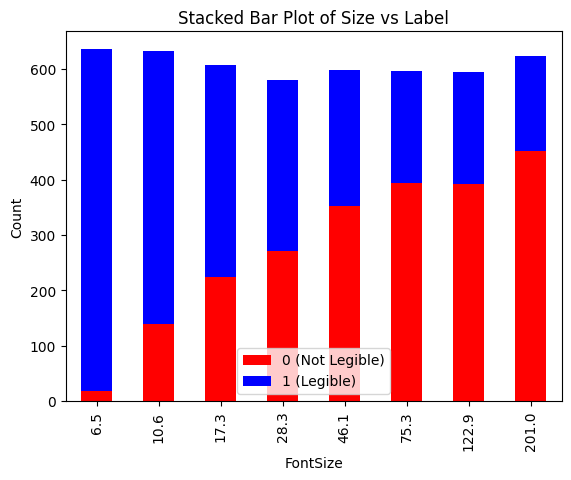

In [17]:
#size vs label distribution
size_label_counts = df.groupby(['FontSize', 'Label']).size().unstack(fill_value=0)

size_label_counts.plot(kind='bar', stacked=True, color=['red', 'blue'])
plt.title('Stacked Bar Plot of Size vs Label')
plt.legend(['0 (Not Legible)', '1 (Legible)'])
plt.xlabel('FontSize')
plt.ylabel('Count')
plt.show()

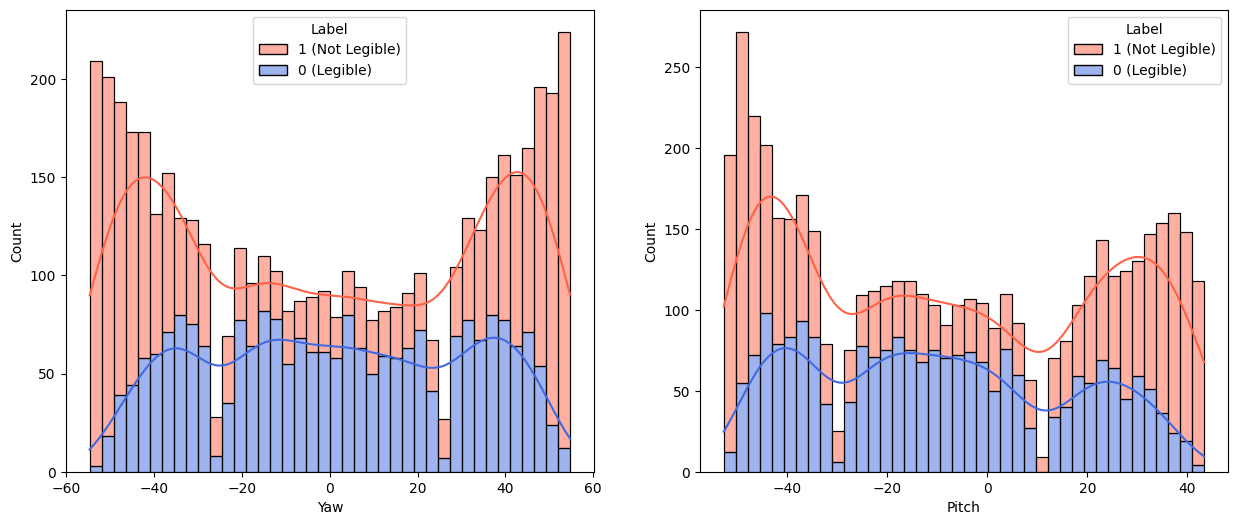

In [31]:
#Distribution of yaw and pitch by Label
df_plot = df.copy()
df_plot['Label'] = df_plot['Label'].map({0: '0 (Legible)', 1: '1 (Not Legible)'})

palette_map = {'0 (Legible)': "royalblue", '1 (Not Legible)': "tomato"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=df_plot, x='Yaw', hue='Label', bins=40, kde=True, 
             multiple='stack', ax=axes[0], palette=palette_map)

sns.histplot(data=df_plot, x='Pitch', hue='Label', bins=40, kde=True, 
             multiple='stack', ax=axes[1], palette=palette_map)

plt.show()